In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

In [28]:
#1. Insurance Data Loaded
df=pd.read_csv('insurance.csv')
df
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


In [29]:
# 2. DATA OPERATIONS/CALCULATIONS
print("2. DATA OPERATIONS/CALCULATIONS:")
print("\nStatistical Summary:")
print(df.describe())

print(f"\nMedian of charges: {df['charges'].median()}")
print(f"Mean of charges: {df['charges'].mean()}")
print(f"Sum of charges: {df['charges'].sum()}")
print(f"Standard Deviation: {df['charges'].std()}")

print(f"\nQuartiles of charges:")
print(f"Q1 (25%): {df['charges'].quantile(0.25)}")
print(f"Q2 (50%): {df['charges'].quantile(0.50)}")
print(f"Q3 (75%): {df['charges'].quantile(0.75)}")



2. DATA OPERATIONS/CALCULATIONS:

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Median of charges: 9382.033
Mean of charges: 13270.422265141257
Sum of charges: 17755824.990759
Standard Deviation: 12110.011236694001

Quartiles of charges:
Q1 (25%): 4740.28715
Q2 (50%): 9382.033
Q3 (75%): 16639.912515


In [30]:
# 3. DATA CLEANING
print("3. DATA CLEANING")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Remove duplicates if any
df = df.drop_duplicates()
print(f"\nAfter removing duplicates: {df.shape[0]} rows")


3. DATA CLEANING

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1

After removing duplicates: 1337 rows


In [31]:
# 4. EXPLORATORY DATA ANALYSIS (Filtering, Grouping, Sorting)
print("4. EXPLORATORY DATA ANALYSIS")

# Filtering
print("\n--- Filtering ---")
smokers = df[df['smoker'] == 'yes']
print(f"Smokers count: {len(smokers)}")
high_charges = df[df['charges'] > 30000]
print(f"People with charges > 30000: {len(high_charges)}")

# Grouping
print("\n--- Grouping ---")
print(df.groupby('smoker')['charges'].mean())
print("\nGroup by region:")
print(df.groupby('region')['charges'].mean())

# Sorting
print("\n--- Sorting ---")
print(df.sort_values('charges', ascending=False).head())

4. EXPLORATORY DATA ANALYSIS

--- Filtering ---


Smokers count: 274
People with charges > 30000: 162

--- Grouping ---
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

Group by region:
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

--- Sorting ---
      age     sex     bmi  children smoker     region      charges
543    54  female  47.410         0    yes  southeast  63770.42801
1300   45    male  30.360         0    yes  southeast  62592.87309
1230   52    male  34.485         3    yes  northwest  60021.39897
577    31  female  38.095         1    yes  northeast  58571.07448
819    33  female  35.530         0    yes  northwest  55135.40209


In [32]:
# 5. PEARSON CORRELATION
print("5. PEARSON CORRELATION")

# For numerical columns only
numerical_df = df[['age', 'bmi', 'children', 'charges']]
correlation_matrix = numerical_df.corr(method='pearson')
print("\nPearson Correlation Matrix:")
print(correlation_matrix)

5. PEARSON CORRELATION

Pearson Correlation Matrix:
               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


6. DATA VISUALIZATION


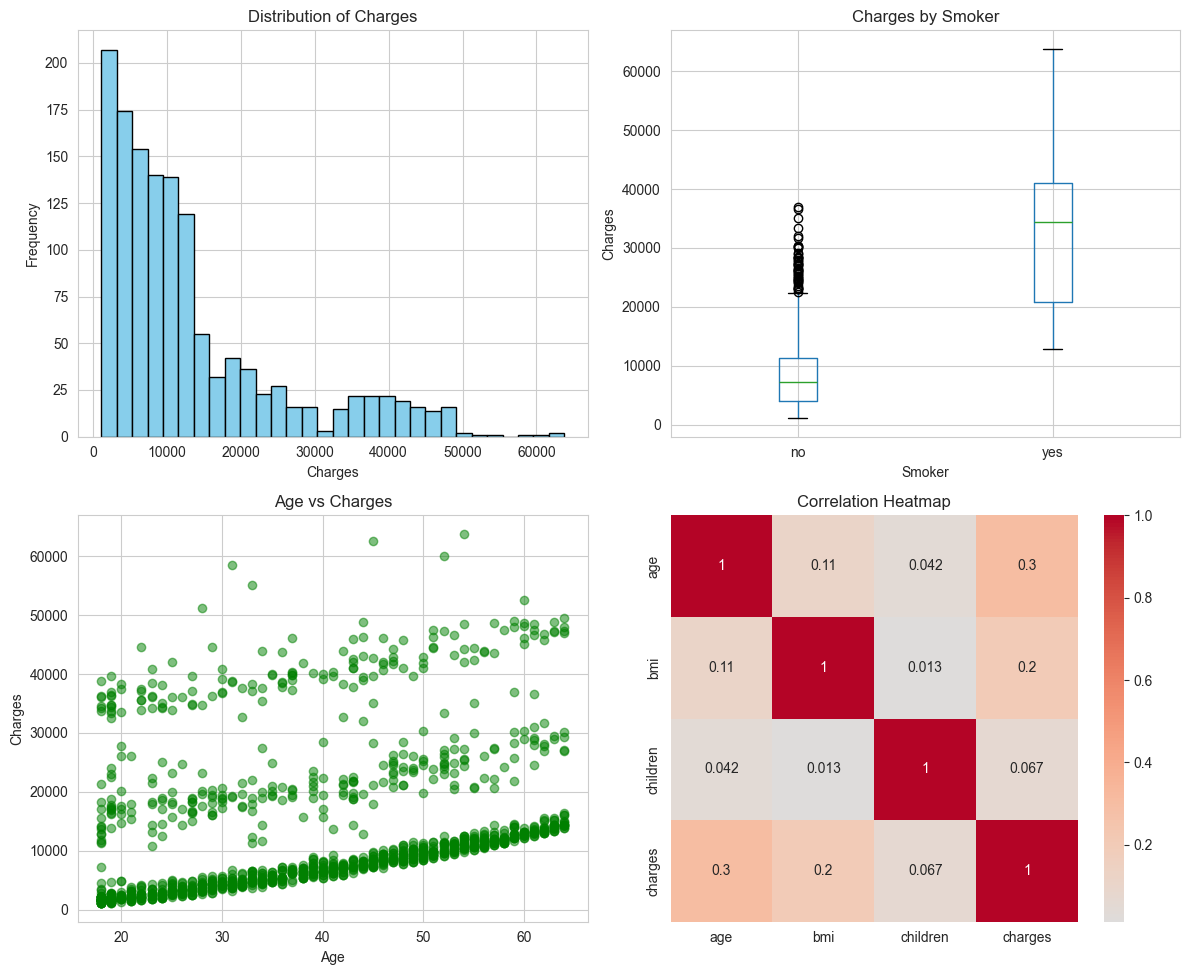

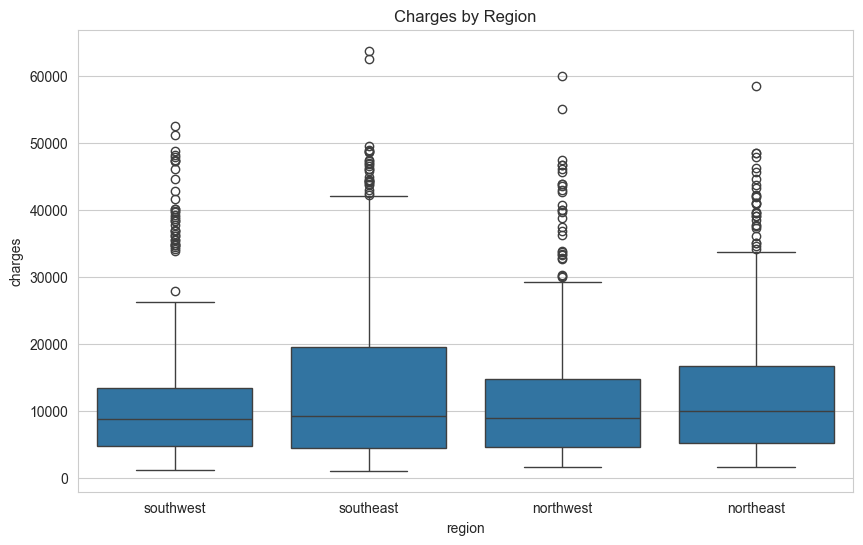

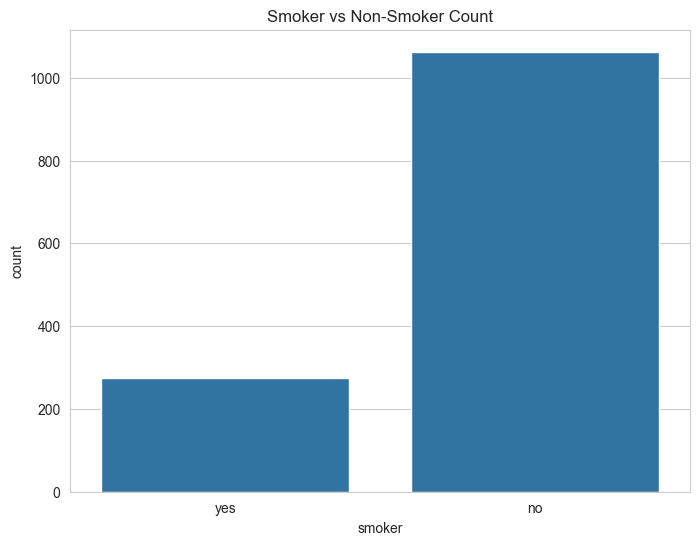

In [33]:
# 6. DATA VISUALIZATION
print("6. DATA VISUALIZATION")

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 10))

# Histogram
plt.subplot(2, 2, 1)
plt.hist(df['charges'], bins=30, edgecolor='black', color='skyblue')
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')

# Box Plot
plt.subplot(2, 2, 2)
df.boxplot(column='charges', by='smoker', ax=plt.gca())
plt.title('Charges by Smoker')
plt.suptitle('')
plt.xlabel('Smoker')
plt.ylabel('Charges')

# Scatter Plot
plt.subplot(2, 2, 3)
plt.scatter(df['age'], df['charges'], alpha=0.5, c='green')
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')

# Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# Additional visualizations
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='smoker', data=df)
plt.title('Smoker vs Non-Smoker Count')
plt.show()


In [34]:
# 7. OUTLIERS DETECTION + REMOVAL

print("7. OUTLIERS DETECTION + REMOVAL")

# IQR Method
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR Method for Charges:")
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

outliers = df[(df['charges'] < lower_bound) | (df['charges'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")

# Remove outliers
df_no_outliers = df[(df['charges'] >= lower_bound) & (df['charges'] <= upper_bound)]
print(f"Dataset after outlier removal: {df_no_outliers.shape[0]} rows")

7. OUTLIERS DETECTION + REMOVAL

IQR Method for Charges:
Q1: 4746.344, Q3: 16657.71745, IQR: 11911.37345
Lower Bound: -13120.716174999998, Upper Bound: 34524.777625
Number of outliers: 139
Dataset after outlier removal: 1198 rows


In [35]:
# 8. DATA LABELING/ENCODING

print("8. DATA LABELING/ENCODING")

df_encoded = df.copy()

# Label Encoding for categorical variables
le = LabelEncoder()
df_encoded['smoker_encoded'] = le.fit_transform(df_encoded['smoker'])
df_encoded['sex_encoded'] = le.fit_transform(df_encoded['sex'])
df_encoded['region_encoded'] = le.fit_transform(df_encoded['region'])

print("\nOriginal categorical columns:")
print(df[['smoker', 'sex', 'region']].head())

print("\nEncoded columns:")
print(df_encoded[['smoker_encoded', 'sex_encoded', 'region_encoded']].head())

# One-Hot Encoding
df_onehot = pd.get_dummies(df, columns=['smoker', 'sex', 'region'], drop_first=True)
print(f"\nAfter One-Hot Encoding shape: {df_onehot.shape}")
print(df_onehot.head())

8. DATA LABELING/ENCODING

Original categorical columns:
  smoker     sex     region
0    yes  female  southwest
1     no    male  southeast
2     no    male  southeast
3     no    male  northwest
4     no    male  northwest

Encoded columns:
   smoker_encoded  sex_encoded  region_encoded
0               1            0               3
1               0            1               2
2               0            1               2
3               0            1               1
4               0            1               1

After One-Hot Encoding shape: (1337, 9)
   age     bmi  children      charges  smoker_yes  sex_male  region_northwest  \
0   19  27.900         0  16884.92400        True     False             False   
1   18  33.770         1   1725.55230       False      True             False   
2   28  33.000         3   4449.46200       False      True             False   
3   33  22.705         0  21984.47061       False      True              True   
4   32  28.880         0   38

In [ ]:
# 9. FEATURE ENGINEERING
print("9. FEATURE ENGINEERING")
df_engineered = df.copy()

# Create new features
df_engineered['age_group'] = pd.cut(df_engineered['age'], 
                                     bins=[0, 25, 35, 50, 100], 
                                     labels=['Young', 'Adult', 'Middle', 'Senior'])

df_engineered['bmi_category'] = pd.cut(df_engineered['bmi'], 
                                        bins=[0, 18.5, 25, 30, 100], 
                                        labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

df_engineered['family_size'] = df_engineered['children'] + 1

df_engineered['has_children'] = (df_engineered['children'] > 0).astype(int)

print("\nNew features created:")
print(df_engineered[['age_group', 'bmi_category', 'family_size', 'has_children']].head())


9. FEATURE ENGINEERING

New features created:
  age_group bmi_category  family_size  has_children
0     Young   Overweight            1             0
1     Young        Obese            2             1
2     Adult        Obese            4             1
3     Adult       Normal            1             0
4     Adult   Overweight            1             0


In [39]:
# 10. DATA SCALING
print("10. DATA SCALING")

scaler = StandardScaler()

# Scale numerical features
numerical_cols = ['age', 'bmi', 'children']
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("\nOriginal values:")
print(df[numerical_cols].head())

print("\nScaled values:")
print(df_scaled[numerical_cols].head())

# 11. T-TEST
print("\n" + "="*50)
print("11. T-TEST")
print("="*50)

10. DATA SCALING

Original values:
   age     bmi  children
0   19  27.900         0
1   18  33.770         1
2   28  33.000         3
3   33  22.705         0
4   32  28.880         0

Scaled values:
        age       bmi  children
0 -1.440418 -0.453160 -0.909234
1 -1.511647  0.509422 -0.079442
2 -0.799350  0.383155  1.580143
3 -0.443201 -1.305052 -0.909234
4 -0.514431 -0.292456 -0.909234

11. T-TEST


In [40]:
# T-test: Smokers vs Non-smokers charges
smokers_charges = df[df['smoker'] == 'yes']['charges']
non_smokers_charges = df[df['smoker'] == 'no']['charges']

t_stat, p_value = ttest_ind(smokers_charges, non_smokers_charges)
print(f"\nT-test: Smokers vs Non-Smokers")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Result: Significant difference between smokers and non-smokers (Reject Null Hypothesis)")
else:
    print("Result: No significant difference (Fail to reject Null Hypothesis)")

# T-test: Male vs Female charges
male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']

t_stat2, p_value2 = ttest_ind(male_charges, female_charges)
print(f"\nT-test: Male vs Female")
print(f"T-statistic: {t_stat2}")
print(f"P-value: {p_value2}")

if p_value2 < 0.05:
    print("Result: Significant difference between genders")
else:
    print("Result: No significant difference between genders")

print("ALL CONCEPTS COMPLETED SUCCESSFULLY!")



T-test: Smokers vs Non-Smokers
T-statistic: 46.64479459840305
P-value: 1.4067220949376035e-282
Result: Significant difference between smokers and non-smokers (Reject Null Hypothesis)

T-test: Male vs Female
T-statistic: 2.124391307062026
P-value: 0.03382079199511948
Result: Significant difference between genders
ALL CONCEPTS COMPLETED SUCCESSFULLY!
